In [2]:
import cv2
import numpy as np
import imutils
from imutils import contours

In [4]:
import matplotlib.pyplot as plt

In [5]:
def show_image(title, img, cmap=None):
    plt.figure(figsize=(10, 8))
    if cmap is None and len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

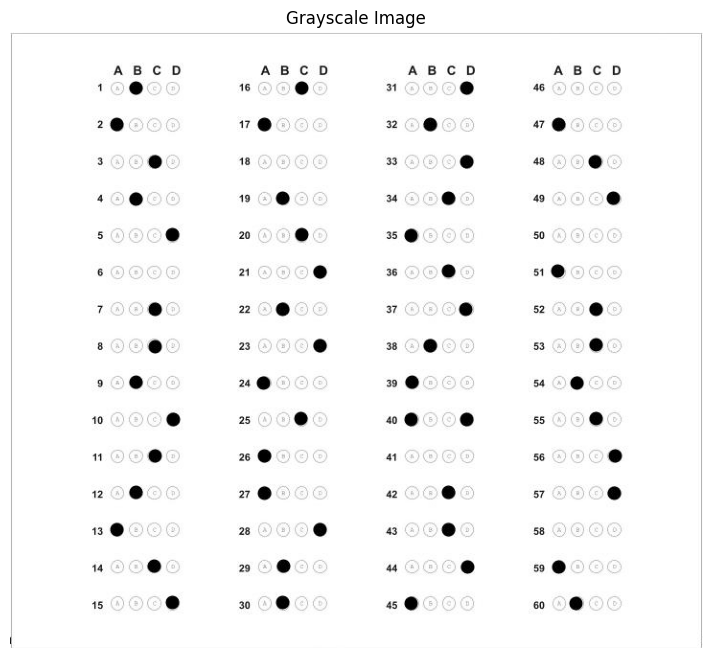

In [6]:
# 1. Load the filled student section
image_path = '../sections/section_5.png'
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load {image_path}")
    exit()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_image("Grayscale Image", gray, cmap='gray')


Found 55 bubbles in this section.


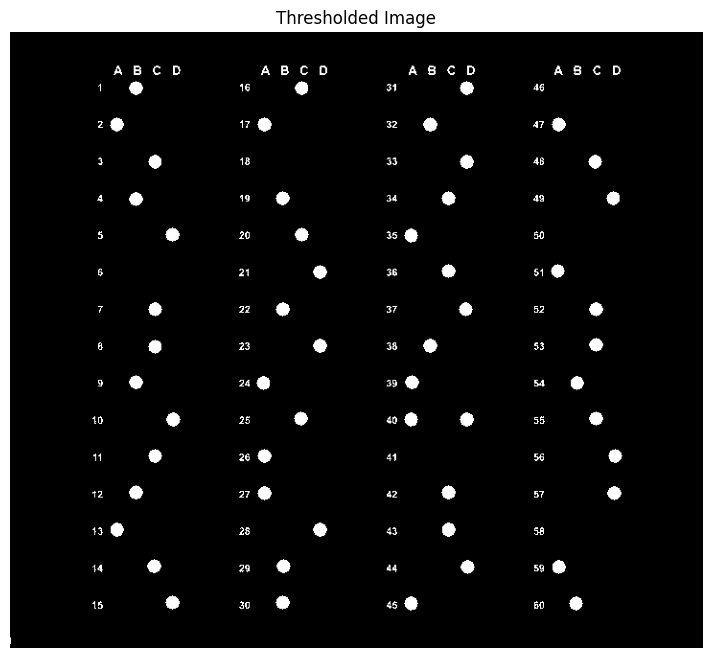

In [ ]:

# 2. Mask by using Thresholding
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]

# Find all contours on the mask
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

question_bubbles = []

# Filter for bubbles
for c in cnts:
    (x, y, w, h) = cv2.boundingRect(c)
    ar = w / float(h)
    # Adjust size in case bubbles are smaller/larger
    if w >= 12 and h >= 12 and 0.8 <= ar <= 1.2:
        question_bubbles.append(c)

print(f"Found {len(question_bubbles)} bubbles in this section.")

show_image("Thresholded Image", thresh, cmap='gray')

Successfully identified 55 labeled answers!
Answers marked: ['1B', '2A', '3C', '4B', '5D', '7C', '8C', '9B', '10D', '11C', '12B', '13A', '14C', '15D', '16C', '17A', '19B', '20C', '21D', '22B', '23D', '24A', '25C', '26A', '27A', '28D', '29B', '30B', '31D', '32B', '33D', '34C', '35A', '36C', '37D', '38B', '39A', '40A', '40D', '42C', '43C', '44D', '45A', '47A', '48C', '49D', '51A', '52C', '53C', '54B', '55C', '56D', '57D', '59A', '60B']


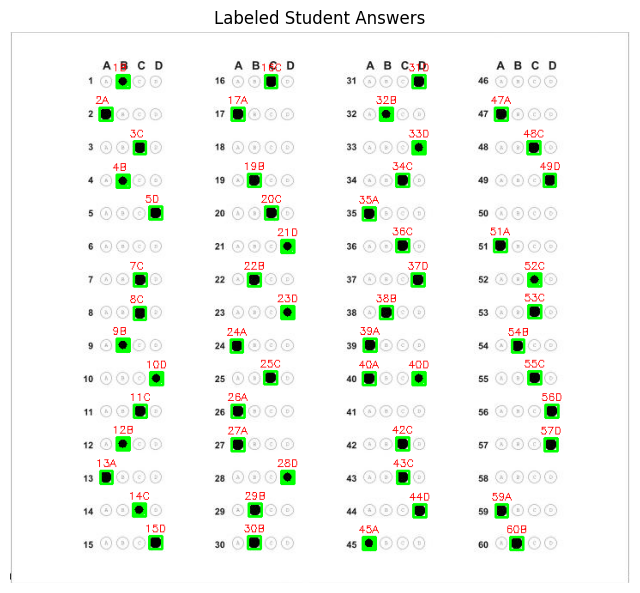

In [ ]:
import json

# 1. Loadsaved JSON map
try:
    with open('omr_template_map.json', 'r') as f:
        omr_map = json.load(f)
except FileNotFoundError:
    print("Error: json not found. Please ensure the file is in the same folder.")
    exit()

filled_labels = []

# 2. Loop through every bubble contour your script just found
for c in question_bubbles:
    # Get bounding box of the found bubble
    x, y, w, h = cv2.boundingRect(c)
    
    # Calculate the exact center point (cx, cy) of this bubble
    cx = x + (w // 2)
    cy = y + (h // 2)
    
    matched_label = None
    
    # 3. Look through the JSON map to see where this center point lands
    for label, box in omr_map.items():
        # Buffer gives a 5-pixel margin of error in case the student bubbled slightly off-center
        buffer = 5 
        
        # Check if the center point (cx, cy) is inside the JSON box
        if (box['x'] - buffer <= cx <= box['x'] + box['w'] + buffer) and \
           (box['y'] - buffer <= cy <= box['y'] + box['h'] + buffer):
            matched_label = label
            break # We found the match, stop searching the map
            
    # 4. If we found a match, draw it on the image and save the label
    if matched_label:
        filled_labels.append(matched_label)
        
        # Draw a green box around the filled bubble
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Draw the text label (e.g., "1A") in red just above the bubble
        cv2.putText(img, matched_label, (x - 5, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

# 5. Sort the labels nicely for the print statement (so 2A comes before 11A)
import re
def sort_key(s):
    parts = re.match(r"(\d+)([A-Z])", s)
    return int(parts.group(1)), parts.group(2)

filled_labels.sort(key=sort_key)

# 6. Show the final results
print(f"Successfully identified {len(filled_labels)} labeled answers!")
print("Answers marked:", filled_labels)

show_image("Labeled Student Answers", img)

      EXAM RESULTS      
Total Questions: 60
Correct Answers: 15
Wrong Answers:   39
Not Answered:    6
Multiple Marks:  1 (counted as wrong)


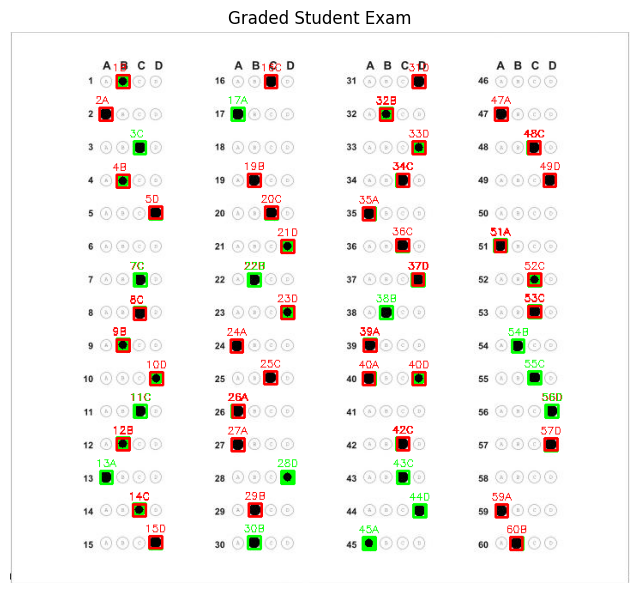

In [ ]:
mock_answers_numbers = [
    1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 
    4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 
    3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 
    2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4
]

import re
import cv2

# --- 1. SETUP THE ANSWER KEY ---
# Replace this with your actual answer key for the 60 questions
# For testing, we are using a repeating pattern: 1A, 2B, 3C, 4D...
test_answers = ['A', 'B', 'C', 'D']
answer_key = {i: test_answers[(i - 1) % 4] for i in range(1, 61)}

# --- 2. ORGANIZE STUDENT RESPONSES ---
# Create a dictionary to hold answers for each of the 60 questions
student_responses = {i: [] for i in range(1, 61)}

for label in filled_labels:
    # Parse "16C" into 16 and "C"
    match = re.match(r"(\d+)([A-Z])", label)
    if match:
        q_num = int(match.group(1))
        letter = match.group(2)
        student_responses[q_num].append(letter)

# --- 3. GRADE THE EXAM & ASSIGN COLORS ---
correct_count = 0
wrong_count = 0
blank_count = 0
multiple_count = 0

# We will store which bubbles to draw and what color they should be
bubbles_to_draw = {} 

for q_num, letters in student_responses.items():
    if len(letters) == 0:
        # Not Answered
        blank_count += 1
        
    elif len(letters) > 1:
        # Multiple Answers Marked
        multiple_count += 1
        wrong_count += 1 # Counts as a wrong answer
        for letter in letters:
            # Mark all chosen bubbles red
            bubbles_to_draw[f"{q_num}{letter}"] = (0, 0, 255) # Red in BGR
            
    else:
        # Exactly 1 Answer Marked
        ans = letters[0]
        correct_ans = answer_key.get(q_num)
        
        if ans == correct_ans:
            correct_count += 1
            bubbles_to_draw[f"{q_num}{ans}"] = (0, 255, 0) # Green in BGR
        else:
            wrong_count += 1
            bubbles_to_draw[f"{q_num}{ans}"] = (0, 0, 255) # Red in BGR

# --- 4. DRAW THE RESULTS ON THE IMAGE ---
# Use the JSON map to get the exact coordinates for drawing
for label, color in bubbles_to_draw.items():
    if label in omr_map:
        box = omr_map[label]
        x, y, w, h = box['x'], box['y'], box['w'], box['h']
        
        # Draw the colored bounding box
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
        
        # Draw the text label
        cv2.putText(img, label, (x - 5, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

# --- 5. PRINT THE GRADING REPORT ---
print("="*30)
print("      EXAM RESULTS      ")
print("="*30)
print(f"Total Questions: 60")
print(f"Correct Answers: {correct_count}")
print(f"Wrong Answers:   {wrong_count}")
print(f"Not Answered:    {blank_count}")
print(f"Multiple Marks:  {multiple_count} (counted as wrong)")
print("="*30)

show_image("Graded Student Exam", img)